# Prognoza cen energii elektrycznej na Rynku Dnia Następnego (Polska)

**Model bazowy dla projektu end-to-end MLOps** (Etap 0: notebook źródłowy).

## Co robi ten notebook
1. Pobiera **godzinowe ceny energii** z Rynku Dnia Następnego (SDAC) z publicznego API PSE — bez klucza, bez rejestracji.
2. Pobiera **pogodę historyczną** dla 10 miast rozłożonych po całej Polsce (Open-Meteo, bez klucza) i uśrednia ją do "pogody krajowej".
3. Buduje **kalendarz** (godzina, dzień tygodnia, święta PL) — wypełnia się sam.
4. Łączy wszystko w **jedną bazę szeregów czasowych** (SQLite + CSV).
5. Trenuje i porównuje modele (baseline naiwny, regresja liniowa, Ridge, las losowy, gradient boosting).
6. Eksportuje **kompletny pipeline** do `models/model.joblib` + metadane + przykładowy rekord (`sample_payload.json`).
7. Robi **prognozę na jutro** (24 godziny) na podstawie prognozy pogody i kalendarza — zmienne wypełniają się same.

## Zmienne modelu (8)
| zmienna | źródło | wypełnianie |
|---|---|---|
| `hour` | kalendarz | automatyczne |
| `day_of_week` | kalendarz | automatyczne |
| `is_holiday_or_weekend` | kalendarz + święta PL | automatyczne |
| `temp_pl` | Open-Meteo, średnia z 10 miast | automatyczne (API) |
| `wind_pl` | Open-Meteo, średnia z 10 miast | automatyczne (API) |
| `radiation_pl` | Open-Meteo, średnia z 10 miast | automatyczne (API) |
| `price_lag_24h` | baza cen PSE | automatyczne (baza) |
| `price_lag_168h` | baza cen PSE | automatyczne (baza) |

Target: `price_pln` — cena godzinowa RDN w PLN/MWh.

## Uczciwe założenia
- Cena RDN jest **jedna dla całej Polski**, dlatego pogoda jest uśredniona krajowo (10 miast, równe wagi). Wiatr i nasłonecznienie to *proxy* generacji wiatrowej i PV — w wersji rozwojowej można je zastąpić prognozami generacji z PSE.
- Dane cen SDAC w API PSE zaczynają się **2024-06-14**.
- Od reformy MTU część danych jest 15-minutowa — kod agreguje wszystko do godzin.
- Notebook wymaga internetu (API PSE i Open-Meteo).

## Sekcja 0. Instalacja i konfiguracja

Cel: ustawiamy zależności, ścieżki, zakres dat i listę miast do uśrednienia pogody.

In [1]:
import importlib, subprocess, sys

# Doinstalowanie brakujących pakietów (bezpieczne przy ponownym uruchomieniu)
for pkg in ["requests", "holidays", "joblib"]:
    try:
        importlib.import_module(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import json
import sqlite3
import time
from datetime import date, datetime, timedelta
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import requests
import sklearn

print("python  :", sys.version.split()[0])
print("pandas  :", pd.__version__)
print("sklearn :", sklearn.__version__)

python  : 3.12.7
pandas  : 3.0.2
sklearn : 1.8.0


In [2]:
# --- KONFIGURACJA PROJEKTU ---------------------------------------------

# Zakres danych historycznych (SDAC w API PSE dostępne od 2024-06-14)
START_DATE = date(2024, 6, 14)
END_DATE   = date.today() - timedelta(days=1)   # do wczoraj

# 10 miast rozłożonych po kraju -> średnia = "pogoda krajowa"
CITIES = {
    "Warszawa":  (52.2297, 21.0122),
    "Krakow":    (50.0647, 19.9450),
    "Lodz":      (51.7592, 19.4560),
    "Wroclaw":   (51.1079, 17.0385),
    "Poznan":    (52.4064, 16.9252),
    "Gdansk":    (54.3520, 18.6466),
    "Szczecin":  (53.4285, 14.5528),
    "Lublin":    (51.2465, 22.5684),
    "Bialystok": (53.1325, 23.1688),
    "Katowice":  (50.2649, 19.0238),
}

WEATHER_VARS = ["temperature_2m", "wind_speed_10m", "shortwave_radiation"]

# Ścieżki wyjściowe (zgodne ze strukturą projektu MLOps)
DATA_DIR    = Path("data");    DATA_DIR.mkdir(exist_ok=True)
MODELS_DIR  = Path("models");  MODELS_DIR.mkdir(exist_ok=True)
SCRIPTS_DIR = Path("scripts"); SCRIPTS_DIR.mkdir(exist_ok=True)
OUTPUTS_DIR = Path("outputs"); OUTPUTS_DIR.mkdir(exist_ok=True)

DB_PATH  = DATA_DIR / "timeseries.db"
CSV_PATH = DATA_DIR / "energy_weather_timeseries.csv"

FEATURES = ["hour", "day_of_week", "is_holiday_or_weekend",
            "temp_pl", "wind_pl", "radiation_pl",
            "price_lag_24h", "price_lag_168h"]
TARGET = "price_pln"

print(f"Zakres danych: {START_DATE} -> {END_DATE}")
print(f"Miasta ({len(CITIES)}):", ", ".join(CITIES))

Zakres danych: 2024-06-14 -> 2026-06-12
Miasta (10): Warszawa, Krakow, Lodz, Wroclaw, Poznan, Gdansk, Szczecin, Lublin, Bialystok, Katowice


In [3]:
# --- Pomocnik HTTP z ponowieniami ---------------------------------------
from urllib.parse import quote

def http_get_json(url, params=None, tries=3, timeout=60):
    """GET z retry. URL budowany recznie: API PSE wymaga literalnego '$filter'
    (nie %24filter), spacji jako %20 i literalnych apostrofow."""
    if params:
        safe_chars = "',:-"
        qs = "&".join(f"{k}={quote(str(v), safe=safe_chars)}"
                      for k, v in params.items())
        url = f"{url}?{qs}"
    last_err = None
    for attempt in range(1, tries + 1):
        try:
            r = requests.get(url, timeout=timeout)
            r.raise_for_status()
            return r.json()
        except Exception as e:          # noqa: BLE001 - celowo szeroki retry
            last_err = e
            time.sleep(2 * attempt)
    raise RuntimeError(f"Nie udalo sie pobrac {url}: {last_err}")

## Sekcja 1. Ceny energii — Rynek Dnia Następnego (API PSE)

Cel: pobieramy godzinowe ceny SDAC (`csdac-pln`) z publicznego API PSE i budujemy szereg czasowy `ts, price_pln`.

Zapytanie dokładnie wg wzorca potwierdzonego w działających integracjach:
`GET https://api.raporty.pse.pl/api/csdac-pln?$filter=business_date eq 'YYYY-MM-DD'`
(spacje kodowane jako `%20` — API PSE odrzuca `+`).

Kod jest defensywny i oszczędny:
- pobiera **dzień po dniu** (jedyny w pełni potwierdzony wzorzec, bez paginacji),
- sam znajduje kolumnę ceny i czasu, agreguje 15 min → godzina,
- **cache w SQLite**: pobrane dni zapisuje od razu do bazy, więc ponowne uruchomienie dociąga tylko brakujące dni.

In [4]:
PSE_API_CSDAC = "https://api.raporty.pse.pl/api/csdac-pln"   # cena RDN (SDAC)
PSE_API_RCE   = "https://api.raporty.pse.pl/api/rce-pln"     # RCE = cena RDN; zapas dla najnowszych dni

def _find_col(df, substrings):
    """Pierwsza kolumna, ktorej nazwa zawiera ktorys z podanych fragmentow."""
    for sub in substrings:
        for c in df.columns:
            if sub in c.lower():
                return c
    return None

def _parse_pse_rows(rows):
    raw = pd.DataFrame(rows)
    price_col = _find_col(raw, ["csdac_pln", "rce_pln", "pln"])
    time_col  = _find_col(raw, ["dtime", "udtczas", "period"])
    if price_col is None or time_col is None:
        raise RuntimeError(f"Nieznany format API PSE. Kolumny: {list(raw.columns)}")
    df = raw[[time_col, price_col]].copy()
    df.columns = ["ts_raw", "price_pln"]
    df["price_pln"] = pd.to_numeric(df["price_pln"], errors="coerce")
    df["ts"] = pd.to_datetime(df["ts_raw"], errors="coerce").dt.floor("h")
    return (df.dropna(subset=["ts", "price_pln"])
              .groupby("ts", as_index=False)["price_pln"].mean()   # 15 min -> 1 h
              .sort_values("ts"))

def fetch_pse_day(d: date) -> pd.DataFrame:
    """Godzinowe ceny RDN dla jednego dnia.
    Zrodlo glowne: csdac-pln. Gdy puste (najnowsze dni bywaja publikowane
    z opoznieniem), zapas: rce-pln (RCE = cena RDN)."""
    for name, api in (("csdac-pln", PSE_API_CSDAC), ("rce-pln", PSE_API_RCE)):
        js = http_get_json(api, params={"$filter": f"business_date eq '{d}'"})
        rows = js.get("value", [])
        if rows:
            if name != "csdac-pln":
                print(f"  {d}: dane ze zrodla zapasowego {name}")
            return _parse_pse_rows(rows)
    return pd.DataFrame(columns=["ts", "price_pln"])

def load_cached_prices() -> pd.DataFrame:
    if not DB_PATH.exists():
        return pd.DataFrame(columns=["ts", "price_pln"])
    try:
        with sqlite3.connect(DB_PATH) as con:
            return pd.read_sql("SELECT ts, price_pln FROM prices", con,
                               parse_dates=["ts"])
    except Exception:
        return pd.DataFrame(columns=["ts", "price_pln"])

def fetch_pse_prices(start: date, end: date) -> pd.DataFrame:
    """Ceny RDN [start, end]: cache z SQLite + dociagniecie brakujacych dni."""
    cached = load_cached_prices()
    have_days = set(cached["ts"].dt.date) if len(cached) else set()
    all_days = [start + timedelta(days=i) for i in range((end - start).days + 1)]
    missing = [d for d in all_days if d not in have_days]
    print(f"Dni w cache: {len(have_days & set(all_days))}, do pobrania: {len(missing)}")

    new_frames = []
    for i, d in enumerate(missing, 1):
        new_frames.append(fetch_pse_day(d))
        if i % 30 == 0 or i == len(missing):
            print(f"  pobrano {i}/{len(missing)} dni (ostatni: {d})")
        time.sleep(0.1)

    frames = ([cached] if len(cached) else []) + new_frames
    full = (pd.concat(frames, ignore_index=True)
              .drop_duplicates("ts").sort_values("ts").reset_index(drop=True))

    with sqlite3.connect(DB_PATH) as con:      # cache: zawsze pelna historia
        full.to_sql("prices", con, if_exists="replace", index=False)

    mask = (full["ts"].dt.date >= start) & (full["ts"].dt.date <= end)
    return full[mask].reset_index(drop=True)

print("Pobieram ceny RDN z PSE (pierwszy raz: kilka minut; potem z cache)...")
prices = fetch_pse_prices(START_DATE, END_DATE)
print(f"\nRazem godzin: {len(prices)}")
prices.tail()

Pobieram ceny RDN z PSE (pierwszy raz: kilka minut; potem z cache)...
Dni w cache: 0, do pobrania: 729


  pobrano 30/729 dni (ostatni: 2024-07-13)


  pobrano 60/729 dni (ostatni: 2024-08-12)


  pobrano 90/729 dni (ostatni: 2024-09-11)


  pobrano 120/729 dni (ostatni: 2024-10-11)


...

  pobrano 690/729 dni (ostatni: 2026-05-04)


  pobrano 720/729 dni (ostatni: 2026-06-03)


  pobrano 729/729 dni (ostatni: 2026-06-12)



Razem godzin: 17494


,ts,price_pln
17489,2026-06-12 19:00:00,529.9450
17490,2026-06-12 20:00:00,595.3250
17491,2026-06-12 21:00:00,647.6275
17492,2026-06-12 22:00:00,543.1300
17493,2026-06-12 23:00:00,443.0900


In [5]:
# TEST POPRAWNOSCI: ceny
assert len(prices) > 5000, "Za malo danych cenowych"
assert prices["ts"].is_monotonic_increasing
assert prices["price_pln"].notna().all()
span_days = (prices["ts"].max() - prices["ts"].min()).days
print(f"OK: {len(prices)} godzin, zakres {prices['ts'].min()} -> {prices['ts'].max()} ({span_days} dni)")
print(f"Cena: min {prices.price_pln.min():.0f}, mediana {prices.price_pln.median():.0f}, max {prices.price_pln.max():.0f} PLN/MWh")

OK: 17494 godzin, zakres 2024-06-14 00:00:00 -> 2026-06-12 23:00:00 (728 dni)
Cena: min -2087, mediana 448, max 2561 PLN/MWh


## Sekcja 2. Pogoda krajowa (Open-Meteo, 10 miast, średnia)

Cel: dla każdej godziny liczymy średnią krajową temperatury, prędkości wiatru i promieniowania słonecznego.

Używamy **Historical Forecast API** Open-Meteo — to te same dane modelowe, z których korzysta API prognozy. Dzięki temu pogoda w treningu i pogoda przy prognozowaniu pochodzą z tego samego źródła (brak rozjazdu trening/produkcja).

In [6]:
OM_HISTORY  = "https://historical-forecast-api.open-meteo.com/v1/forecast"
OM_FORECAST = "https://api.open-meteo.com/v1/forecast"

def _weather_json_to_df(js_one_city: dict) -> pd.DataFrame:
    h = js_one_city["hourly"]
    df = pd.DataFrame({"ts": pd.to_datetime(h["time"])})
    for v in WEATHER_VARS:
        df[v] = h[v]
    return df

def fetch_weather(url: str, start: date | None = None, end: date | None = None,
                  forecast_days: int | None = None) -> pd.DataFrame:
    """Pogoda dla wszystkich miast jednym zapytaniem; zwraca srednia krajowa."""
    params = {
        "latitude":  ",".join(str(lat) for lat, _ in CITIES.values()),
        "longitude": ",".join(str(lon) for _, lon in CITIES.values()),
        "hourly": ",".join(WEATHER_VARS),
        "timezone": "Europe/Warsaw",
    }
    if start is not None:
        params["start_date"] = str(start)
        params["end_date"] = str(end)
    if forecast_days is not None:
        params["forecast_days"] = forecast_days

    js = http_get_json(url, params=params)
    cities_js = js if isinstance(js, list) else [js]
    per_city = [_weather_json_to_df(c) for c in cities_js]

    allc = pd.concat(per_city, ignore_index=True)
    national = (allc.groupby("ts", as_index=False)[WEATHER_VARS].mean()
                    .rename(columns={"temperature_2m": "temp_pl",
                                     "wind_speed_10m": "wind_pl",
                                     "shortwave_radiation": "radiation_pl"}))
    return national.sort_values("ts").reset_index(drop=True)

print("Pobieram pogode historyczna (10 miast)...")
weather = fetch_weather(OM_HISTORY, start=START_DATE, end=END_DATE)
print(f"Godzin pogody: {len(weather)} (usredniono z {len(CITIES)} miast)")
weather.tail()

Pobieram pogode historyczna (10 miast)...


Godzin pogody: 17496 (usredniono z 10 miast)


,ts,temp_pl,wind_pl,radiation_pl
17491,2026-06-12 19:00:00,17.27,8.71,157.8
17492,2026-06-12 20:00:00,16.69,8.58,80.5
17493,2026-06-12 21:00:00,15.83,7.45,17.3
17494,2026-06-12 22:00:00,15.20,7.49,0.2
17495,2026-06-12 23:00:00,14.60,7.20,0.0


In [7]:
# TEST POPRAWNOSCI: pogoda
assert {"temp_pl", "wind_pl", "radiation_pl"}.issubset(weather.columns)
assert weather["temp_pl"].between(-35, 45).all(), "Podejrzane temperatury"
assert (weather["radiation_pl"] >= 0).all()
cov = len(set(prices["ts"]) & set(weather["ts"])) / len(prices)
print(f"OK: pokrycie czasowe ceny<->pogoda: {cov:.1%}")
assert cov > 0.95, "Pogoda nie pokrywa szeregu cen"

OK: pokrycie czasowe ceny<->pogoda: 100.0%


## Sekcja 3. Kalendarz (wypełnia się sam)

Cel: godzina, dzień tygodnia oraz flaga "weekend lub święto" (kalendarz świąt PL z pakietu `holidays`).

In [8]:
try:
    import holidays as _hol
    PL_HOLIDAYS = _hol.country_holidays("PL", years=range(START_DATE.year, END_DATE.year + 2))
    print(f"Kalendarz swiat PL: {len(PL_HOLIDAYS)} dni (pakiet holidays)")
except Exception as e:
    PL_HOLIDAYS = {}
    print("UWAGA: pakiet holidays niedostepny, uzywam samych weekendow.", e)

def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["hour"] = out["ts"].dt.hour
    out["day_of_week"] = out["ts"].dt.dayofweek          # 0 = poniedzialek
    is_weekend = out["day_of_week"] >= 5
    is_holiday = out["ts"].dt.date.map(lambda d: d in PL_HOLIDAYS)
    out["is_holiday_or_weekend"] = (is_weekend | is_holiday).astype(int)
    return out

Kalendarz swiat PL: 55 dni (pakiet holidays)


## Sekcja 4. Baza szeregów czasowych (SQLite + CSV)

Cel: jedna tabela `energy_weather` — ceny połączone z pogodą i kalendarzem. To jest "baza danych cen w formie szeregów czasowych połączona z bazą pogody". Z niej będzie korzystać aplikacja (lagi) i monitoring dryftu (dane referencyjne).

In [9]:
ds = prices.merge(weather, on="ts", how="inner")
ds = add_calendar_features(ds)

def add_lag(df: pd.DataFrame, hours: int) -> pd.DataFrame:
    """Dodaje kolumne price_lag_{hours}h przez przesuniecie szeregu cen."""
    lag = df[["ts", "price_pln"]].copy()
    lag["ts"] = lag["ts"] + pd.Timedelta(hours=hours)
    lag = lag.rename(columns={"price_pln": f"price_lag_{hours}h"})
    return df.merge(lag, on="ts", how="left")

ds = add_lag(ds, 24)
ds = add_lag(ds, 168)
ds = ds.dropna(subset=FEATURES + [TARGET]).reset_index(drop=True)

# Zapis do SQLite i CSV (tabela prices jest juz zapisana w Sekcji 1)
with sqlite3.connect(DB_PATH) as con:
    weather.to_sql("weather", con, if_exists="replace", index=False)
    ds.to_sql("energy_weather", con, if_exists="replace", index=False)
ds.to_csv(CSV_PATH, index=False)

# Dane referencyjne pod monitoring dryftu (Etap 2 projektu MLOps)
ds[FEATURES + [TARGET]].to_csv(DATA_DIR / "reference_data.csv", index=False)

print(f"Wierszy w zbiorze: {len(ds)}")
print(f"Zapisano: {DB_PATH}, {CSV_PATH}, data/reference_data.csv")
ds[["ts", TARGET] + FEATURES].tail(3)

Wierszy w zbiorze: 17322
Zapisano: data/timeseries.db, data/energy_weather_timeseries.csv, data/reference_data.csv


,ts,price_pln,hour,day_of_week,is_holiday_or_weekend,temp_pl,wind_pl,radiation_pl,price_lag_24h,price_lag_168h
17319,2026-06-12 21:00:00,647.6275,21,4,0,15.83,7.45,17.3,716.6025,788.1600
17320,2026-06-12 22:00:00,543.1300,22,4,0,15.20,7.49,0.2,583.9025,720.8300
17321,2026-06-12 23:00:00,443.0900,23,4,0,14.60,7.20,0.0,512.3325,651.2625


In [10]:
# TEST POPRAWNOSCI: baza
with sqlite3.connect(DB_PATH) as con:
    n_db = pd.read_sql("SELECT COUNT(*) AS n FROM energy_weather", con)["n"].iloc[0]
assert n_db == len(ds)
assert ds[FEATURES].notna().all().all()
print(f"OK: SQLite zawiera {n_db} wierszy, komplet cech bez brakow")

OK: SQLite zawiera 17322 wierszy, komplet cech bez brakow


## Sekcja 5. Szybki rzut oka na dane

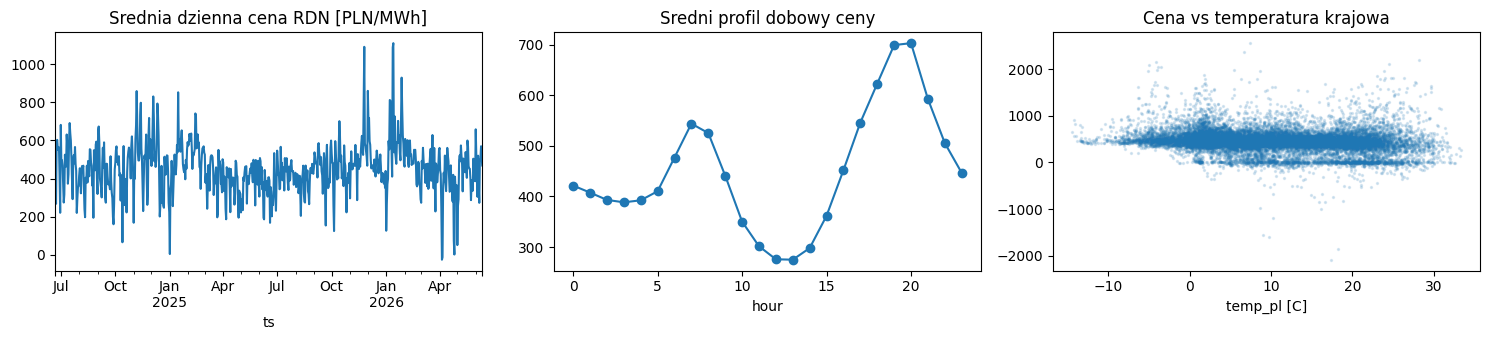

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
ds.set_index("ts")[TARGET].resample("D").mean().plot(ax=axes[0], title="Srednia dzienna cena RDN [PLN/MWh]")
ds.groupby("hour")[TARGET].mean().plot(ax=axes[1], marker="o", title="Sredni profil dobowy ceny")
axes[2].scatter(ds["temp_pl"], ds[TARGET], s=2, alpha=0.15)
axes[2].set_title("Cena vs temperatura krajowa"); axes[2].set_xlabel("temp_pl [C]")
plt.tight_layout(); plt.show()

## Sekcja 6. Podział czasowy train/test

Cel: ostatnie 60 dni to test (symulacja produkcji). Szeregów czasowych **nie** dzielimy losowo.

In [12]:
split_ts = ds["ts"].max() - pd.Timedelta(days=60)
train = ds[ds["ts"] <= split_ts]
test  = ds[ds["ts"] >  split_ts]

X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]
print(f"Train: {len(train)} h (do {split_ts:%Y-%m-%d}), Test: {len(test)} h")
assert len(test) > 1000

Train: 15882 h (do 2026-04-13), Test: 1440 h


## Sekcja 7. Modele i porównanie

Cel: porównujemy modele z **baselinem naiwnym** (cena sprzed tygodnia). Model ma sens tylko, jeżeli bije baseline. Każdy kandydat to kompletny `Pipeline` (skalowanie + model) — gotowy do eksportu w całości.

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

def make_pipeline(model):
    pre = ColumnTransformer([("num", StandardScaler(), FEATURES)])
    return Pipeline([("preprocessing", pre), ("model", model)])

candidates = {
    "LinearRegression": make_pipeline(LinearRegression()),
    "Ridge_a10":        make_pipeline(Ridge(alpha=10)),
    "RandomForest":     make_pipeline(RandomForestRegressor(
                            n_estimators=300, min_samples_leaf=5,
                            random_state=42, n_jobs=-1)),
    "HistGB":           make_pipeline(HistGradientBoostingRegressor(
                            max_iter=400, learning_rate=0.06, random_state=42)),
}

def evaluate(y_true, y_pred):
    return {"MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": root_mean_squared_error(y_true, y_pred),
            "R2": r2_score(y_true, y_pred)}

results = {"Baseline_naive_lag168": evaluate(y_test, X_test["price_lag_168h"])}
fitted = {}
for name, pipe in candidates.items():
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    results[name] = evaluate(y_test, pipe.predict(X_test))
    print(f"trained: {name}")

results_df = (pd.DataFrame(results).T
                .sort_values("MAE")
                .round({"MAE": 2, "RMSE": 2, "R2": 3}))
results_df

trained: LinearRegression
trained: Ridge_a10


trained: RandomForest


trained: HistGB


,MAE,RMSE,R2
HistGB,85.15,144.60,0.724
RandomForest,86.86,146.90,0.715
Ridge_a10,98.92,168.38,0.626
LinearRegression,98.92,168.38,0.626
Baseline_naive_lag168,150.43,266.80,0.061


In [14]:
# TEST POPRAWNOSCI: najlepszy model musi bic baseline naiwny
best_name = results_df.drop(index="Baseline_naive_lag168")["MAE"].idxmin()
best_mae  = results_df.loc[best_name, "MAE"]
base_mae  = results_df.loc["Baseline_naive_lag168", "MAE"]
print(f"Najlepszy model: {best_name} (MAE {best_mae:.2f} vs baseline {base_mae:.2f} PLN/MWh)")
assert best_mae < base_mae, "Model nie bije baselinu - nie eksportuj!"
print(f"OK: model lepszy od baselinu o {100*(1-best_mae/base_mae):.1f}%")

Najlepszy model: HistGB (MAE 85.15 vs baseline 150.43 PLN/MWh)
OK: model lepszy od baselinu o 43.4%


## Sekcja 8. Eksport modelu (artefakty pod Etap 1 MLOps)

Cel: zapisujemy **kompletny pipeline** (preprocessing + model) do `models/model.joblib`, metadane do `models/model_metadata.json` i realny przykładowy rekord do `scripts/sample_payload.json`. Na końcu **samokontrola parytetu**: wczytany z dysku model musi dawać identyczne predykcje jak model w pamięci.

In [15]:
champion = fitted[best_name]

# 1) Artefakt modelu (kompletny pipeline)
model_path = MODELS_DIR / "model.joblib"
joblib.dump(champion, model_path)

# 2) Metadane
metadata = {
    "model_name": "pl_day_ahead_power_price",
    "champion": best_name,
    "target": TARGET,
    "target_unit": "PLN/MWh",
    "features": FEATURES,
    "train_range": [str(train["ts"].min()), str(train["ts"].max())],
    "test_range":  [str(test["ts"].min()),  str(test["ts"].max())],
    "metrics_test": {k: round(float(v), 3) for k, v in results_df.loc[best_name].items()},
    "baseline_naive_mae": round(float(base_mae), 3),
    "sklearn_version": sklearn.__version__,
    "exported_at": datetime.now().isoformat(timespec="seconds"),
    "data_sources": {
        "prices": "PSE api.raporty.pse.pl / csdac-pln (RDN/SDAC)",
        "weather": f"Open-Meteo, srednia z {len(CITIES)} miast: {', '.join(CITIES)}",
    },
}
(MODELS_DIR / "model_metadata.json").write_text(
    json.dumps(metadata, indent=2, ensure_ascii=False), encoding="utf-8")

# 3) Przykladowy rekord do testow API (realny wiersz z testu)
sample_row = X_test.iloc[-1]
sample_payload = {k: (int(v) if k in ("hour", "day_of_week", "is_holiday_or_weekend")
                      else round(float(v), 2)) for k, v in sample_row.items()}
(SCRIPTS_DIR / "sample_payload.json").write_text(
    json.dumps(sample_payload, indent=2), encoding="utf-8")

print("Zapisano:", model_path, ", model_metadata.json, sample_payload.json")
print("Przykladowy rekord:", sample_payload)

Zapisano: models/model.joblib , model_metadata.json, sample_payload.json
Przykladowy rekord: {'hour': 23, 'day_of_week': 4, 'is_holiday_or_weekend': 0, 'temp_pl': 14.6, 'wind_pl': 7.2, 'radiation_pl': 0.0, 'price_lag_24h': 512.33, 'price_lag_168h': 651.26}


In [16]:
# TEST PARYTETU: model z dysku == model w pamieci
reloaded = joblib.load(model_path)
sample_X = X_test.tail(50)
pred_mem  = champion.predict(sample_X)
pred_disk = reloaded.predict(sample_X)
assert np.allclose(pred_mem, pred_disk, rtol=1e-9), "Parytet nie przeszedl!"
one = reloaded.predict(pd.DataFrame([sample_payload]))[0]
print(f"OK: parytet na 50 wierszach zgodny; predykcja dla sample_payload: {one:.2f} PLN/MWh")

OK: parytet na 50 wierszach zgodny; predykcja dla sample_payload: 574.45 PLN/MWh


## Sekcja 9. Prognoza na jutro (zmienne wypełniają się same)

Cel: pokazujemy pełny cykl produkcyjny — **prognoza pogody z API** + **kalendarz** + **lagi z bazy** budują wektor cech dla 24 godzin jutrzejszego dnia, a model zwraca prognozę cen. Dokładnie to samo będzie robić aplikacja FastAPI.

Uwaga: ceny RDN na jutro PSE publikuje ok. 13:00–14:00. Nasza prognoza ma sens przed publikacją; po publikacji służy do **weryfikacji** (porównanie prognozy z ceną rzeczywistą = monitoring jakości na produkcji).

Cechy na jutro gotowe: 24/24 godzin (ostatnia cena w bazie: 2026-06-13 00:00:00)


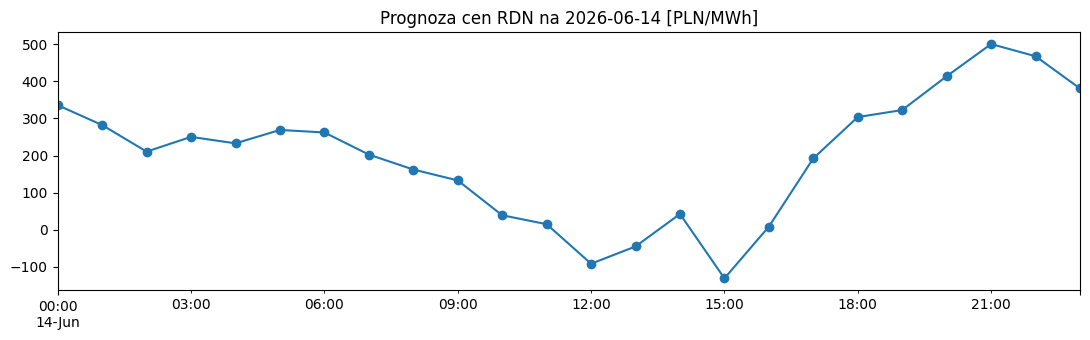

,ts,predicted_price_pln,hour,day_of_week,is_holiday_or_weekend,temp_pl,wind_pl,radiation_pl,price_lag_24h,price_lag_168h
0,2026-06-14 00:00:00,335.601491,0,6,1,13.86,14.39,0.0,411.9,507.4600
1,2026-06-14 01:00:00,281.957358,1,6,1,13.59,14.97,0.0,411.9,461.4975
2,2026-06-14 02:00:00,210.497294,2,6,1,13.02,15.58,0.0,411.9,424.5825
3,2026-06-14 03:00:00,250.201627,3,6,1,12.56,15.97,0.0,411.9,386.2900
4,2026-06-14 04:00:00,232.718942,4,6,1,12.23,15.74,0.0,411.9,392.5875
5,2026-06-14 05:00:00,268.847133,5,6,1,11.89,15.06,5.6,411.9,393.6250
6,2026-06-14 06:00:00,262.053419,6,6,1,11.98,15.11,47.3,411.9,414.2450
7,2026-06-14 07:00:00,202.470292,7,6,1,12.35,16.34,111.4,411.9,253.2425
8,2026-06-14 08:00:00,162.224057,8,6,1,12.74,18.02,185.8,411.9,10.1000
9,2026-06-14 09:00:00,132.888702,9,6,1,13.25,17.60,249.1,411.9,-13.0550


In [17]:
def build_tomorrow_features() -> pd.DataFrame:
    tomorrow = date.today() + timedelta(days=1)

    # 1) Pogoda na jutro: prognoza z tego samego zrodla co dane treningowe
    wf = fetch_weather(OM_FORECAST, forecast_days=2)
    wf = wf[wf["ts"].dt.date == tomorrow].copy()
    if len(wf) == 0:
        raise RuntimeError("Brak prognozy pogody na jutro z Open-Meteo")

    # 2) Kalendarz: wypelnia sie sam
    feat = add_calendar_features(wf)

    # 3) Historia cen z bazy + dociagniecie najswiezszych dni (dzis/wczoraj)
    with sqlite3.connect(DB_PATH) as con:
        hist = pd.read_sql("SELECT ts, price_pln FROM prices", con,
                           parse_dates=["ts"])
    last_day = hist["ts"].dt.date.max()
    if last_day < date.today():
        try:
            fresh = fetch_pse_prices(last_day, date.today())
            hist = (pd.concat([hist, fresh]).drop_duplicates("ts")
                      .sort_values("ts").reset_index(drop=True))
            # zapis dociagnietych cen do cache, zeby aplikacja tez je miala
            with sqlite3.connect(DB_PATH) as con:
                hist.to_sql("prices", con, if_exists="replace", index=False)
        except Exception as e:
            print("Uwaga: nie udalo sie dociagnac najswiezszych cen:", e)

    # 4) Lagi: dla kazdej godziny jutra cena sprzed 24 h i sprzed 168 h.
    #    Zamiast twardego dopasowania znacznika uzywamy reindex+ffill/bfill,
    #    co odpornie radzi sobie z pojedynczymi dziurami i zmiana czasu.
    s = (hist.dropna(subset=["price_pln"])
             .drop_duplicates("ts").set_index("ts")["price_pln"]
             .sort_index())
    full_idx = pd.date_range(s.index.min(), s.index.max(), freq="h")
    s = s.reindex(full_idx).ffill().bfill()   # uzupelnij brakujace godziny

    def lag_value(t, hours):
        key = t - pd.Timedelta(hours=hours)
        if key in s.index:
            return float(s.loc[key])
        # poza zakresem (np. lag wykracza przed start danych) -> najblizsza znana
        pos = s.index.searchsorted(key)
        pos = min(max(pos, 0), len(s) - 1)
        return float(s.iloc[pos])

    feat["price_lag_24h"]  = feat["ts"].map(lambda t: lag_value(t, 24))
    feat["price_lag_168h"] = feat["ts"].map(lambda t: lag_value(t, 168))

    n_missing = int(feat[FEATURES].isna().sum().sum())
    if n_missing:
        print(f"Uwaga: {n_missing} brakow w cechach po uzupelnieniu - sprawdz dane")
    out = feat.dropna(subset=FEATURES).reset_index(drop=True)
    print(f"Cechy na jutro gotowe: {len(out)}/24 godzin "
          f"(ostatnia cena w bazie: {s.index.max()})")
    return out

tom = build_tomorrow_features()
tom["predicted_price_pln"] = reloaded.predict(tom[FEATURES])
tom_out = tom[["ts", "predicted_price_pln"] + FEATURES]
tom_out.to_csv(OUTPUTS_DIR / "prediction_next_day.csv", index=False)

ax = tom.set_index("ts")["predicted_price_pln"].plot(
    marker="o", figsize=(11, 3.5),
    title=f"Prognoza cen RDN na {date.today() + timedelta(days=1)} [PLN/MWh]")
ax.set_xlabel(""); plt.tight_layout(); plt.show()
tom_out.head(24)

In [18]:
# TEST POPRAWNOSCI: prognoza na jutro
assert len(tom) >= 1, "Brak prognozy na jutro - sprawdz pogode i ceny w bazie"
assert tom["predicted_price_pln"].between(-1000, 8000).all(), "Predykcje poza sensownym zakresem"

godzin = len(tom)
if godzin >= 23:
    print(f"OK: prognoza na jutro obejmuje pelna dobe ({godzin} godzin), "
          f"srednia {tom.predicted_price_pln.mean():.0f} PLN/MWh "
          f"-> outputs/prediction_next_day.csv")
else:
    # mniej niz pelna doba zdarza sie tylko przed publikacja swiezych cen/pogody;
    # to nie blad - to naturalna sytuacja wczesnym rankiem
    print(f"OK (czesciowo): prognoza obejmuje {godzin}/24 godzin "
          f"(zwykle przy uruchomieniu przed publikacja swiezych danych). "
          f"srednia {tom.predicted_price_pln.mean():.0f} PLN/MWh "
          f"-> outputs/prediction_next_day.csv")

OK: prognoza na jutro obejmuje pelna dobe (24 godzin), srednia 198 PLN/MWh -> outputs/prediction_next_day.csv


## Podsumowanie i artefakty

Po pełnym przebiegu notebooka istnieją:

| plik | rola w projekcie MLOps |
|---|---|
| `data/timeseries.db` | baza szeregów czasowych: tabele `prices`, `weather`, `energy_weather` |
| `data/energy_weather_timeseries.csv` | kopia zbioru w CSV |
| `data/reference_data.csv` | dane referencyjne pod raport dryftu (Etap 2) |
| `models/model.joblib` | kompletny pipeline (preprocessing + model) — artefakt dla FastAPI (Etap 1) |
| `models/model_metadata.json` | cechy, metryki, wersja sklearn, źródła danych |
| `scripts/sample_payload.json` | realny rekord do testów `/predict` (Etap 1) |
| `outputs/prediction_next_day.csv` | prognoza na jutro — wzorzec działania aplikacji |

**Pętla weryfikacji (serce projektu):** dziś prognozujemy jutrzejsze ceny; jutro po ~13:00 PSE publikuje ceny rzeczywiste → porównanie daje dzienne MAE na produkcji. To zadanie dla retrainingu i monitoringu w Etapach 2–3.

**Świadome uproszczenia (kandydaci na rozwój):** równe wagi miast zamiast ważenia populacją/mocą; wiatr i nasłonecznienie zamiast prognoz generacji z PSE; brak cech paliwowych (gaz, CO2).